In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier
import seaborn as sns


In [2]:
#pip install xgboost
from google.colab import files
uploaded = files.upload()

Saving Data_PEI_2019-2023.xlsx to Data_PEI_2019-2023.xlsx


In [3]:

# Load the dataset
df1 = pd.read_excel("Data_PEI_2019-2023.xlsx")



In [4]:
# Encode categorical variables
df1['Crop Disease'] = df1['Crop Disease'].astype("category").cat.codes
df1['Location'] = df1['Location'].astype("category").cat.codes


In [5]:

# Ensure the "Date" column is valid for conversion
df1["Date"] = pd.to_datetime(df1["Date"], errors='coerce')
if df1["Date"].isna().any():
    print("Invalid dates found:")
    print(df1[df1["Date"].isna()])



Class distribution in target variable:
DSI
1    1207
0     275
Name: count, dtype: int64


<Axes: xlabel='DSI', ylabel='count'>

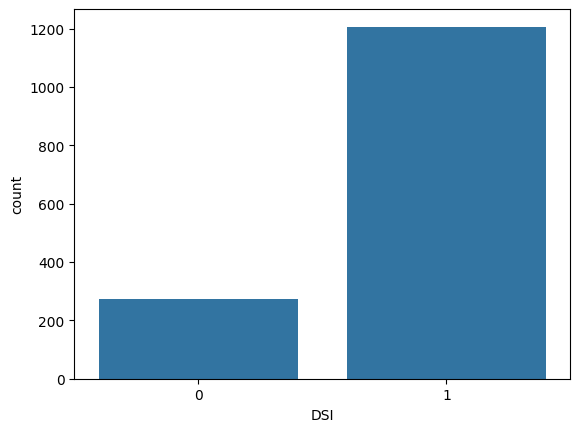

In [6]:
# Drop the "Date" column
df1 = df1.drop(["Date"], axis=1)

# Separate features and target variable
X = df1.drop(['DSI', 'Province', 'Spore Trapping'], axis=1)
y = df1['DSI']

# Check class distribution
print("Class distribution in target variable:")
print(y.value_counts())
sns.countplot(x=y)



In [7]:
# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Verify shapes
print(f"Training data: {X_train.shape}, Testing data: {X_test.shape}")

# Standard scaling
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)


Training data: (1185, 11), Testing data: (297, 11)


In [ ]:

# Random Forest Classifier (baseline)
r = RandomForestClassifier(random_state=42, n_estimators=1000)
r.fit(X_train, y_train)
y_pred = r.predict(X_test)



Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.71      0.73        55
           1       0.93      0.95      0.94       242

    accuracy                           0.90       297
   macro avg       0.84      0.83      0.83       297
weighted avg       0.90      0.90      0.90       297

Confusion Matrix (Random Forest):


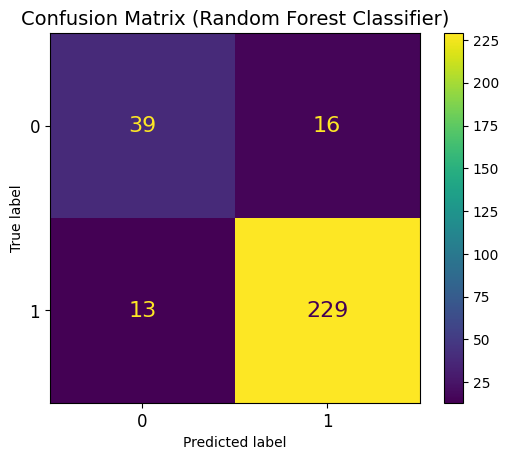

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Initialize and train Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluation: Random Forest
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

print("Confusion Matrix (Random Forest):")
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Display confusion matrix
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot()
plt.title("Confusion Matrix (Random Forest Classifier)", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

for labels in disp_rf.text_:
  for label in labels:
    label.set_fontsize(16)

plt.show()



In [ ]:
disease_accuracy = accuracy_score(y_test, y_pred)
print(disease_accuracy)
from sklearn.metrics import precision_score, recall_score, f1_score
disease_precision = precision_score(y_test, y_pred, average='binary')
print(f"Precision: {disease_precision}")
disease_recall = recall_score(y_test, y_pred, average='binary')
print(f"Recall: {disease_recall}")
disease_f1 = f1_score(y_test, y_pred, average='binary')
print(f"F1-Score: {disease_f1}")

0.898989898989899
Precision: 0.9308943089430894
Recall: 0.9462809917355371
F1-Score: 0.9385245901639344


In [ ]:

# Hyperparameter tuning for XGBoost
from sklearn.model_selection import GridSearchCV
# param grid: defines the hyperparameters to tune
param_grid = {
    'n_estimators': [100, 200, 300], #number of trees in XGboost
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_alpha': [0.1, 0.5],
    'reg_lambda': [1, 2]
}

grid_search = GridSearchCV(
    XGBClassifier(random_state=42),
    param_grid,
    cv=3,
    verbose=2,
    n_jobs=-1  #n_jobs=-1: Utilizes all available CPU cores for parallel processing.
)
grid_search.fit(X_train, y_train)
print("Best Parameters (XGBoost):", grid_search.best_params_)



Fitting 3 folds for each of 432 candidates, totalling 1296 fits
Best Parameters (XGBoost): {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'reg_alpha': 0.1, 'reg_lambda': 1, 'subsample': 0.8}


In [ ]:
# Train XGBoost with best parameters
xgb = XGBClassifier(random_state=42, **grid_search.best_params_)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)



XGBoost Accuracy: 0.8956228956228957
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.65      0.70        55
           1       0.92      0.95      0.94       242

    accuracy                           0.90       297
   macro avg       0.84      0.80      0.82       297
weighted avg       0.89      0.90      0.89       297



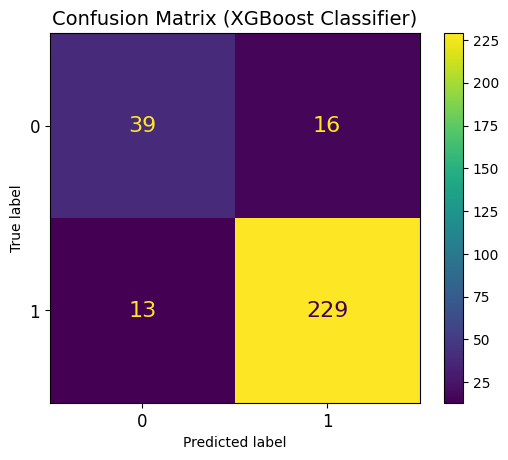

In [ ]:
# Evaluation: XGBoost
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_xgb.plot()
plt.title("Confusion Matrix (XGBoost Classifier)", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

for labels in disp_xgb.text_:
  for label in labels:
    label.set_fontsize(16)

plt.show()

In [ ]:

# Cross-validation with stratified folds
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb, X, y, cv=skf, scoring='accuracy')
print("Cross-Validation Accuracy (XGBoost):", cv_scores.mean())


Cross-Validation Accuracy (XGBoost): 0.8751683501683502


In [ ]:
cv_scores = cross_val_score(r, X, y, cv=skf, scoring='accuracy')
print("Cross-Validation Accuracy (random):", cv_scores.mean())

Cross-Validation Accuracy (random): 0.8616753116753116


In [ ]:

# # Feature importance visualization (XGBoost)
# from xgboost import plot_importance
# import matplotlib.pyplot as plt

# plt.figure(figsize=(10, 8))
# plot_importance(xgb)
# plt.title("Feature Importance (XGBoost)")
# plt.show()


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression



GaussianNB Classifier:
TSImple Model est Accuracy: 0.8114
Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.29      0.36        55
           1       0.85      0.93      0.89       242

    accuracy                           0.81       297
   macro avg       0.67      0.61      0.63       297
weighted avg       0.78      0.81      0.79       297



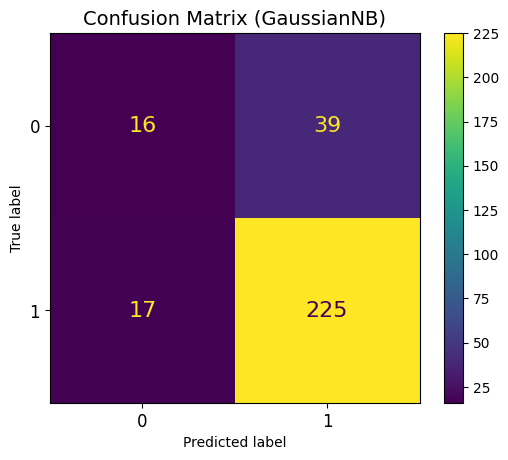

accuracy 0.8114478114478114
Cross-Validation Precision: 0.8522727272727273
Cross-Validation Recall: 0.9297520661157025
Cross-Validation F1-Score: 0.8893280632411067
Cross-Validation Metrics (5 folds):
Accuracy: 0.7996 ± 0.0059

KNeighborsClassifier Classifier:
TSImple Model est Accuracy: 0.8384
Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.44      0.50        55
           1       0.88      0.93      0.90       242

    accuracy                           0.84       297
   macro avg       0.73      0.68      0.70       297
weighted avg       0.82      0.84      0.83       297



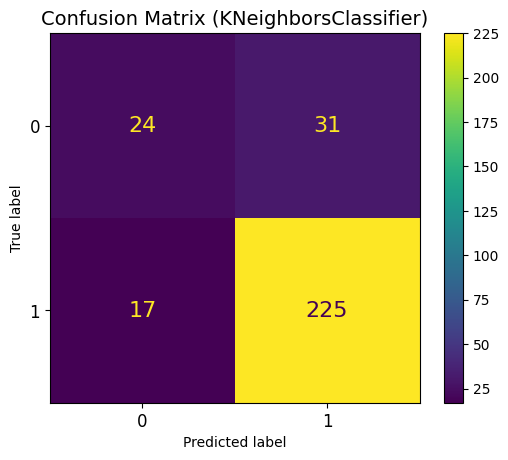

accuracy 0.8383838383838383
Cross-Validation Precision: 0.87890625
Cross-Validation Recall: 0.9297520661157025
Cross-Validation F1-Score: 0.9036144578313253
Cross-Validation Metrics (5 folds):
Accuracy: 0.8151 ± 0.0159

Decision Tree Classifier Classifier:
TSImple Model est Accuracy: 0.8653
Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.73      0.67        55
           1       0.94      0.90      0.92       242

    accuracy                           0.87       297
   macro avg       0.78      0.81      0.79       297
weighted avg       0.88      0.87      0.87       297



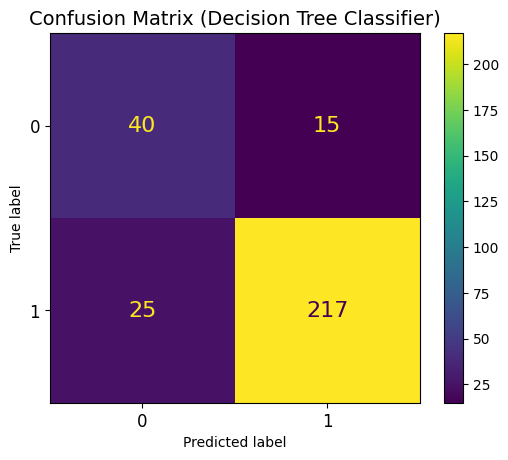

accuracy 0.8653198653198653
Cross-Validation Precision: 0.9353448275862069
Cross-Validation Recall: 0.8966942148760331
Cross-Validation F1-Score: 0.9156118143459916
Cross-Validation Metrics (5 folds):
Accuracy: 0.8381 ± 0.0203

LogisticRegression Classifier:
TSImple Model est Accuracy: 0.8249
Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.15      0.24        55
           1       0.83      0.98      0.90       242

    accuracy                           0.82       297
   macro avg       0.72      0.56      0.57       297
weighted avg       0.79      0.82      0.78       297



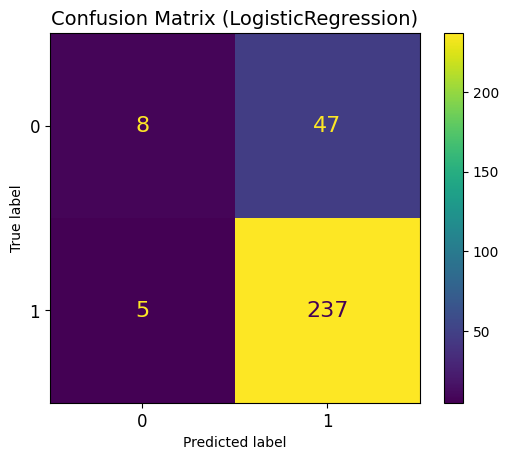

accuracy 0.8249158249158249
Cross-Validation Precision: 0.8345070422535211
Cross-Validation Recall: 0.9793388429752066
Cross-Validation F1-Score: 0.9011406844106464


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Cross-Validation Metrics (5 folds):
Accuracy: 0.8165 ± 0.0052


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:

# Initialize classifiers
gnb = GaussianNB()
knn = KNeighborsClassifier(n_neighbors=5)  # Default: 5 neighbors
dt = DecisionTreeClassifier(random_state=42)
lr = LogisticRegression(random_state=42, max_iter=1000)  # Increased max_iter for convergence

# List of classifiers for iteration
classifiers = {
    "GaussianNB": gnb,
    "KNeighborsClassifier": knn,
    "Decision Tree Classifier": dt,
    "LogisticRegression": lr
}

# Number of cross-validation folds
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Train, evaluate, and perform cross-validation for each classifier
for name, clf in classifiers.items():
    print(f"\n{name} Classifier:")

    # Train the classifier
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    # Accuracy and classification report
    print(f"TSImple Model est Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix ({name})", fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    # Adjust inside label font size
    for labels in disp.text_:  # Update text labels
        for label in labels:
            label.set_fontsize(16)
    # plt.show()
     # Confusion matrix
    # cm = confusion_matrix(y_test, y_pred)
    # disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    # fig, ax = plt.subplots(figsize=(8, 6))  # Adjust figure size
    # disp.plot(ax=ax, cmap='viridis', colorbar=False)
    # plt.title(f"Confusion Matrix ({name})", fontsize=16)
    # plt.xticks(fontsize=14)
    # plt.yticks(fontsize=14)

    # # Adjust inside label font size
    # for labels in disp.text_:  # Update text labels
    #     for label in labels:
    #         label.set_fontsize(18)



    plt.show()

    disease_accuracy = accuracy_score(y_test, y_pred)
    print("accuracy", disease_accuracy)
    # Precision, Recall, and F1-Score without cross-validation
    precision_scores = precision_score(y_test, y_pred, average='binary')
    print("Cross-Validation Precision:", precision_scores)

    recall_scores = recall_score(y_test, y_pred, average='binary')
    print("Cross-Validation Recall:", recall_scores)

    f1_scores = f1_score(y_test, y_pred, average='binary')
    print("Cross-Validation F1-Score:", f1_scores)

    # Perform cross-validation for multiple metrics
    accuracy_scores = cross_val_score(clf, X, y, cv=skf, scoring='accuracy')
    print(f"Cross-Validation Metrics ({n_splits} folds):")
    print(f"Accuracy: {accuracy_scores.mean():.4f} ± {accuracy_scores.std():.4f}")


GaussianNB Classifier:
TSImple Model est Accuracy: 0.8114
Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.29      0.36        55
           1       0.85      0.93      0.89       242

    accuracy                           0.81       297
   macro avg       0.67      0.61      0.63       297
weighted avg       0.78      0.81      0.79       297



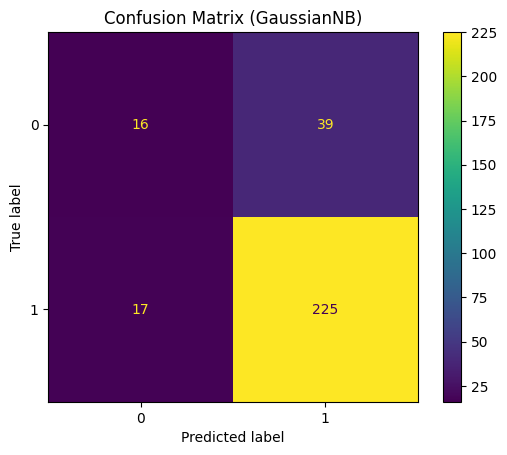

Cross-Validation Accuracy (5 folds): 0.7996 ± 0.0059

KNeighborsClassifier Classifier:
TSImple Model est Accuracy: 0.8384
Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.44      0.50        55
           1       0.88      0.93      0.90       242

    accuracy                           0.84       297
   macro avg       0.73      0.68      0.70       297
weighted avg       0.82      0.84      0.83       297



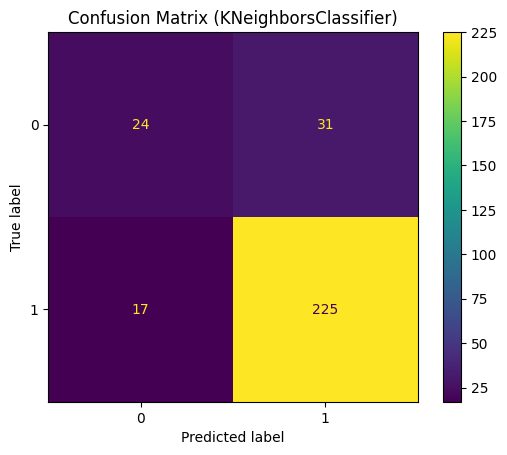

Cross-Validation Accuracy (5 folds): 0.8151 ± 0.0159

DecisionTreeClassifier Classifier:
TSImple Model est Accuracy: 0.8653
Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.73      0.67        55
           1       0.94      0.90      0.92       242

    accuracy                           0.87       297
   macro avg       0.78      0.81      0.79       297
weighted avg       0.88      0.87      0.87       297



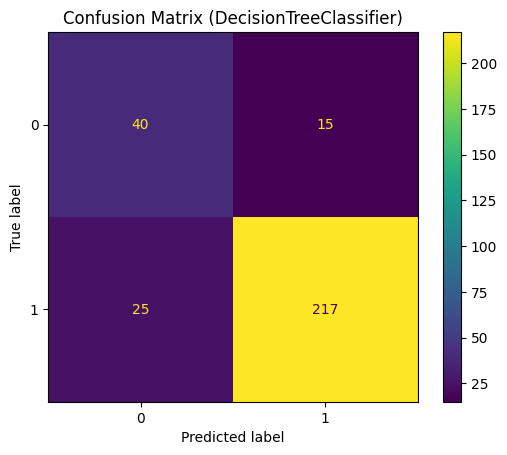

Cross-Validation Accuracy (5 folds): 0.8381 ± 0.0203

LogisticRegression Classifier:
TSImple Model est Accuracy: 0.8249
Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.15      0.24        55
           1       0.83      0.98      0.90       242

    accuracy                           0.82       297
   macro avg       0.72      0.56      0.57       297
weighted avg       0.79      0.82      0.78       297



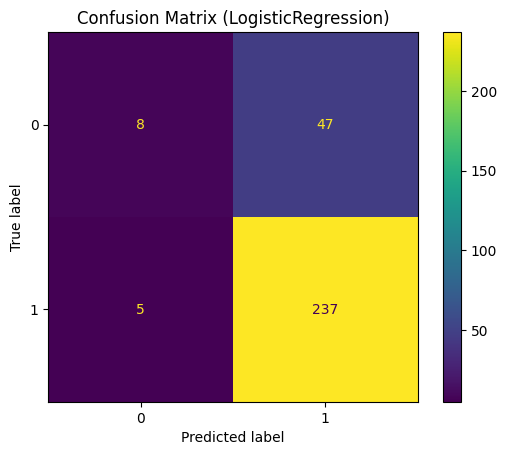

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Cross-Validation Accuracy (5 folds): 0.8165 ± 0.0052


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:

# Initialize classifiers
gnb = GaussianNB()
knn = KNeighborsClassifier(n_neighbors=5)  # Default: 5 neighbors
dt = DecisionTreeClassifier(random_state=42)
lr = LogisticRegression(random_state=42, max_iter=1000)  # Increased max_iter for convergence

# List of classifiers for iteration
classifiers = {
    "GaussianNB": gnb,
    "KNeighborsClassifier": knn,
    "DecisionTreeClassifier": dt,
    "LogisticRegression": lr
}

# Number of cross-validation folds
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Train, evaluate, and perform cross-validation for each classifier
for name, clf in classifiers.items():
    print(f"\n{name} Classifier:")

    # Train the classifier
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    # Accuracy and classification report
    print(f"TSImple Model est Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix ({name})")
    plt.show()

    # Perform cross-validation
    cv_scores = cross_val_score(clf, X, y, cv=skf, scoring='accuracy')
    print(f"Cross-Validation Accuracy ({n_splits} folds): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


In [ ]:
#  Final result graphs

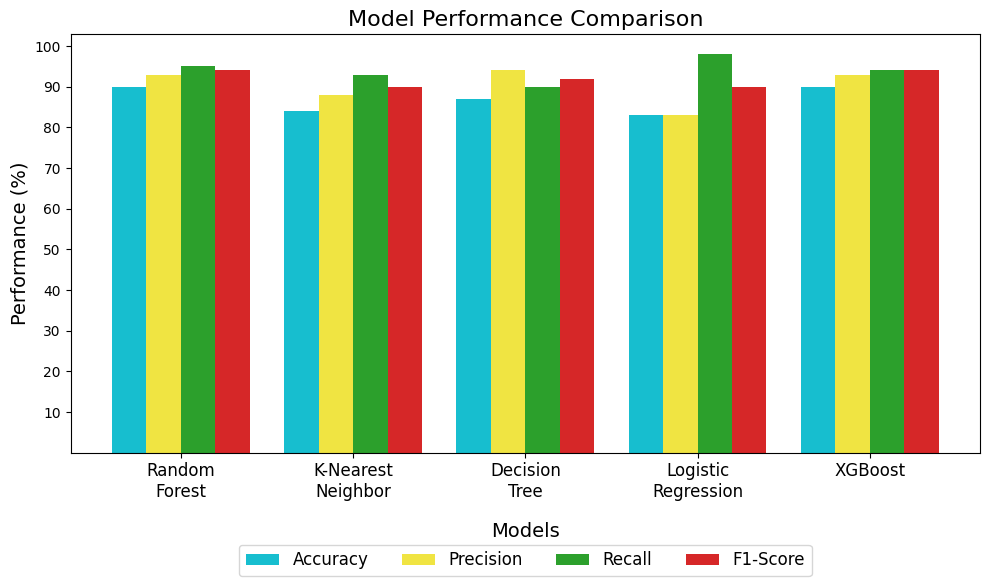

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Performance metrics for models
models = ['Random\nForest', 'K-Nearest\nNeighbor', 'Decision\nTree',
          'Logistic\nRegression', 'XGBoost']
accuracy = [90, 84, 87, 83, 90]
precision = [93, 88, 94, 83, 93]
recall = [95,93,90,98,94]
f1_score = [94,90,92,90,94]

# Grouped bar chart
x = np.arange(len(models))
width = 0.2

# Define custom colors
colors = ['#17becf', '#f0e442', '#2ca02c', '#d62728']

plt.figure(figsize=(10, 6))
plt.bar(x - 1.5 * width, accuracy, width, color=colors[0], label='Accuracy')
plt.bar(x - 0.5 * width, precision, width, color=colors[1], label='Precision')
plt.bar(x + 0.5 * width, recall, width, color=colors[2], label='Recall')
plt.bar(x + 1.5 * width, f1_score, width, color=colors[3], label='F1-Score')

# Custom X and Y ticks
plt.xticks(x, models, fontsize=12)
plt.yticks(np.arange(10, 110, 10))  # Y-axis ticks from 10 to 100 with a step of 10

# Labels and title
plt.xlabel('Models', fontsize=14, labelpad=15)  # Padding for x-axis title
plt.ylabel('Performance (%)', fontsize=14)
plt.title('Model Performance Comparison', fontsize=16)


# Move legend outside the plot
plt.legend(fontsize=12, loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=4)
plt.subplots_adjust(bottom=0.15)
plt.tight_layout()
plt.show()
